### Loading ad preping the data

In [3]:
import pandas as pd
import numpy as np
%pip install hdbscan

summary_df = pd.read_csv("summary.csv")
static_df = pd.read_csv("static.csv")
df = summary_df.merge(static_df, on = "RunID", how = "inner")
feature_cols = [
        # "max_cpu_usage_percent",
        "mean_cpu_usage_percent",
        # "max_ram_used_mb",
        "mean_ram_used_mb",
        "time_per_1000_steps_sec"
    ]
assert len(df) == len(summary_df), "Different number of entries"
# print(df.head())
print(static_df["game_name"].value_counts(normalize=True))
print(static_df["training_type"].value_counts(normalize=True))

Note: you may need to restart the kernel to use updated packages.
game_name
3DBall               0.460666
3DBallHard           0.339121
Crawler              0.071580
GridFoodCollector    0.057229
PushBlock            0.029943
Hallway              0.021262
Pyramids             0.004429
Walker               0.004429
Worm                 0.004429
Sorter               0.003898
GridWorld            0.003012
Name: proportion, dtype: float64
training_type
ppo    0.980865
sac    0.019135
Name: proportion, dtype: float64


In [42]:
pd.crosstab(df["game_name"], df["training_type"])

training_type,ppo,sac
game_name,,
3DBall,2571,29
3DBallHard,1902,12
Crawler,386,18
GridFoodCollector,316,7
GridWorld,15,2
Hallway,112,8
PushBlock,162,7
Pyramids,18,7
Sorter,18,4


In [60]:
def create_feature_data_frame(df : pd.DataFrame) -> pd.DataFrame:
    assert (df["max_steps"] > 0).all(), "Runs with 0 steps found"
    df["time_per_1000_steps_sec"] = (df["total_duration_sec"]/df["max_steps"]*1000)
    return df[feature_cols]
    
def get_sanitized_mask(X : pd.DataFrame):
    sanitized_mask =(
        # (X["max_cpu_usage_percent"] >= 0) &
        (X["mean_cpu_usage_percent"] >= 0) &
        # (X["max_ram_used_mb"] >= 0) &
        (X["mean_ram_used_mb"] >= 0) &
        (X["time_per_1000_steps_sec"] > 0)
    )
    return sanitized_mask

def get_subsample_mask(sanitized_df : pd.DataFrame, instances_per_machine_game_pair = 5):
    subsampled = sanitized_df.groupby(["cpu", "game_name", "training_type"], group_keys=False).apply(
        lambda x: x.sample(
            n=min(len(x), instances_per_machine_game_pair),
            random_state=42
        )
    )
    used_run_ids = set(subsampled["RunID"])
    return sanitized_df["RunID"].isin(used_run_ids)

X = create_feature_data_frame(df)
sanitized_mask = get_sanitized_mask(X)
X_sanitized = X[sanitized_mask].copy()
df_sanitized = df[sanitized_mask].copy()
subsample_mask = get_subsample_mask(df_sanitized)

X_sanitized = X_sanitized[subsample_mask]
df_sanitized = df_sanitized[subsample_mask]

def get_sanitized_and_subsampled_features_and_org_df(df : pd.DataFrame, subsample = True, subsample_cap = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    X = create_feature_data_frame(df)
    sanitized_mask = get_sanitized_mask(X)
    X_sanitized = X[sanitized_mask].copy()
    df_sanitized = df[sanitized_mask].copy()
    if subsample:
        subsample_mask = get_subsample_mask(df_sanitized, instances_per_machine_game_pair=subsample_cap)
        X_sanitized = X_sanitized[subsample_mask].copy()
        df_sanitized = df_sanitized[subsample_mask].copy()
    return X_sanitized, df_sanitized

print(f"Number of significantly long runs (time_per_1000_stpes_sec > 10) : {len(X[X["time_per_1000_steps_sec"]>10])}")
print(f"Number of deleted entries : {len(X) - len(X_sanitized)}")
print(f"Number of entires remainig : {len(X_sanitized)}")

Number of significantly long runs (time_per_1000_stpes_sec > 10) : 83
Number of deleted entries : 5362
Number of entires remainig : 282


In [5]:
filtered = (df["game_name"] == "3DBall") & (df["training_type"] == "sac")
X_sanitized[filtered].describe()

/var/folders/fp/hb4266ks69q8sbbntv5rmj2w0000gn/T/ipykernel_77531/1868267825.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_sanitized[filtered].describe()


,mean_cpu_usage_percent,mean_ram_used_mb,time_per_1000_steps_sec
count,15.000000,15.000000,15.000000
mean,23.265266,8197.712306,10.409248
std,5.585442,7196.852216,10.116320
min,16.166667,2904.025830,2.918337
25%,18.869939,2965.551459,4.159030
50%,22.218167,3591.258325,6.029525
75%,26.581125,17751.552675,11.825956
max,33.568833,18245.840000,39.201016


In [59]:
import matplotlib.pyplot as plt

def plot_distribuiton_of_features() -> None:        
    for col in feature_cols:
        plt.figure()
        plt.hist(X[col].dropna(), bins=100)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    plt.figure()
    selected = X[X["time_per_1000_steps_sec"] > 10]
    ax = plt.axes()
    ax.set_xscale("log")
    plt.hist(selected["time_per_1000_steps_sec"].dropna(), bins=100)
    
    plt.title(f"Distribution of time_per_1000_steps_sec")
    plt.xlabel("time_per_1000_steps_sec")
    plt.ylabel("Count")
    plt.show()
    
# plot_distribuiton_of_features()


In [7]:
print(static_df.cpu.unique())
print(len(static_df[static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor"]))
# test = static_df[static_df["cpu"] == "Apple M1"]
# print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "AMD Ryzen 7 9800X3D 8-Core Processor") & (static_df["training_type"] == "sac")]
print(test["training_type"].value_counts())
print(test["game_name"].value_counts())
test = static_df[(static_df["cpu"] == "Apple M1") & (static_df["training_type"] == "sac")]
print(len(test))

['AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD' 'Apple M2'
 'AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD'
 'AMD Ryzen 7 9800X3D 8-Core Processor'
 'AMD Ryzen 7 5700X 8-Core Processor' 'Apple M1']
4144
training_type
sac    8
Name: count, dtype: int64
game_name
Crawler              1
GridFoodCollector    1
Hallway              1
PushBlock            1
Pyramids             1
Sorter               1
Walker               1
Worm                 1
Name: count, dtype: int64
38


In [57]:
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def get_scaled_df_and_np(X_sanitized : pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray]:
    scaler = RobustScaler()
    X_log = X_sanitized.copy()
    X_log["time_per_1000_steps_sec"] = np.log1p(X_log["time_per_1000_steps_sec"])
    X_log["mean_ram_used_mb"] = np.log1p(X_log["mean_ram_used_mb"])
    X_scaled_as_array = scaler.fit_transform(X_log)
    X_scaled = pd.DataFrame(
        X_scaled_as_array,
        columns=X_sanitized.columns,
        index = X_sanitized.index
    )
    return X_scaled, X_scaled_as_array

def cluster(X_scaled_as_array : np.ndarray, n_init = "auto", n_clusters = 5) -> tuple[np.ndarray, KMeans]:
    clf = KMeans(n_clusters=n_clusters, random_state=42, n_init=n_init, init="k-means++")
    clusters = clf.fit_predict(X_scaled_as_array)    
    return clusters, clf
    
def cluster_and_show(n_init = "auto", n_clusters = 5) -> None:
    X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
    X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
    X_scaled.describe()

    X_scaled["clusters"] = cluster(X_scaled_as_array, n_init=n_init, n_clusters = n_clusters)[0]
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.scatter(X_pca[:, 0], X_pca[:, 1], c = X_scaled["clusters"])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()
    
def show_clustered(X_scaled) -> None:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    clusters = X_scaled["cluster"].unique()

    for cluster in clusters:
        mask = X_scaled["cluster"] == cluster
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f"Cluster {cluster}"
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Clusters")
    plt.show()

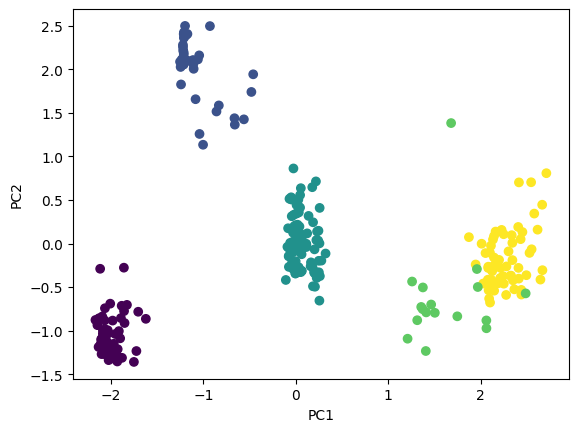

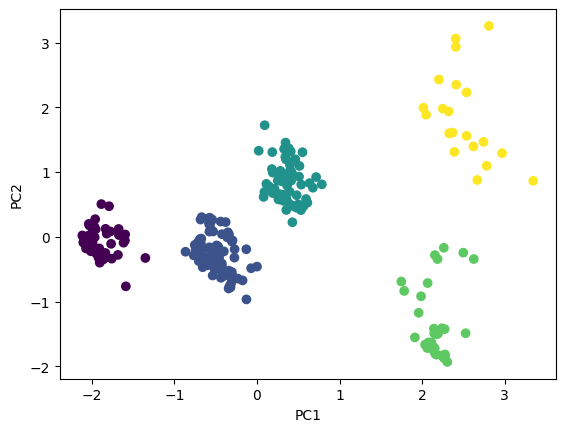

In [9]:
cluster_and_show(n_init="auto")
cluster_and_show(n_init=10)



In [10]:
import numpy as np
pca = PCA(n_components=2)
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
X_pca_1 = pca.fit_transform(X_scaled)
X_pca_2 = pca.fit_transform(X_scaled)

np.allclose(X_pca_1, X_pca_2)

labels_auto = KMeans(n_clusters=5, n_init="auto", random_state=42).fit_predict(X_scaled)
labels_10 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)

(labels_auto == labels_10).mean()


0.26595744680851063

In [11]:
clusters, clf = cluster(X_scaled_as_array)
X_sanitized["cluster"] = clf.labels_
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
# print(cluster_summary)
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = X_sanitized["cluster"]
# static_cluster_3 = df_sanitized.loc[X_sanitized["cluster"] == 3]
# print(static_cluster_3)
# static_cluster_3.head()
# X_sanitized[X_sanitized["cluster"] == 3]["RunID"]
# X_sanitized
# print(summary_df_sanitized[X_sanitized["cluster"] == 3])
# df_sanitized[X_sanitized["cluster"] == 3]
# df_sanitized_with_clusters.head()
print(df_sanitized_with_clusters.columns)
print(X_sanitized["cluster"].value_counts())

Index(['RunID', 'final_reward', 'max_reward', 'time_to_max_reward_sec',
       'total_duration_sec', 'mean_policy_loss', 'mean_value_loss',
       'mean_entropy', 'final_entropy', 'max_cpu_usage_percent',
       'mean_cpu_usage_percent', 'max_ram_used_mb', 'mean_ram_used_mb',
       'mean_cpu_frequency', 'max_cpu_frequency', 'max_gpu_usage_percent',
       'mean_gpu_usage_percent', 'max_vram_used_mb', 'mean_vram_used_mb',
       'max_game_cpu_usage_percent', 'mean_game_cpu_usage_percent',
       'max_game_memory_usage_mb', 'mean_game_memory_usage_mb', 'os', 'cpu',
       'physical_cores', 'system_ram_gb', 'gpu', 'GPU_ram_mb', 'cuda_version',
       'training_type', 'game_name', 'batch_size', 'learning_rate',
       'buffer_size', 'beta', 'epsilon', 'lambd', 'num_epoch',
       'learning_rate_schedule', 'normalize', 'hidden_units', 'num_layers',
       'vis_encode_type', 'reward_extrinsic_gamma',
       'reward_extrinsic_strength', 'keep_checkpoints', 'max_steps',
       'time_horizon',

In [12]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"])

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,11,6,6,5,5,5,5,6,5,5,5
1,10,6,6,6,0,6,2,2,1,2,2
2,14,6,10,8,1,9,10,9,7,10,12
3,0,1,2,4,2,2,1,0,4,0,1
4,10,6,12,4,1,6,5,6,3,6,3


In [13]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
cluster,,
0,60,4
1,36,7
2,84,12
3,1,16
4,11,51


In [14]:
pd.crosstab(df_sanitized_with_clusters["game_name"],df_sanitized_with_clusters["training_type"])

training_type,ppo,sac
game_name,,
3DBall,30,15
3DBallHard,15,10
Crawler,20,16
GridFoodCollector,20,7
GridWorld,7,2
Hallway,20,8
PushBlock,16,7
Pyramids,16,7
Sorter,16,4


In [15]:
pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["cpu"])

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
0,59,0,5,0,0,0
1,0,37,0,5,0,1
2,0,0,0,0,48,48
3,13,1,0,0,2,1
4,11,0,0,0,33,18


In [16]:
display(cluster_summary)
display(df_sanitized_with_clusters)

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                     6.761728   4.310187   1.737500  22.218167   
1                    63.537707   5.619206  47.310843  73.460501   
2                    27.639089   5.794394  16.166667  42.872490   
3                    17.613182  11.340672   4.636000  55.329807   
4                    24.151094   6.858369  12.765000  45.424243   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0           13406.646839  4062.502570  8451.416748  21702.772358   
1           20857.958449  3334.315582  4220.743938  24726.250000   
2            3447.642701   254.071185  2588.723328   4047.323743   
3           12991.065395  5327.600045  2823.696663  19947.100000   
4            5071.505218  4192.715495  2660.485742  18245.840000   

        time_per_1000_steps_sec                                     
                           mean         std        min         max  
cluster                                                             
0                      1.445106    1.424372   0.412098    8.201914  
1                      2.695701    5.415037   0.230291   23.334980  
2                      2.199043    1.414930   0.627457    5.954784  
3                    145.810584  232.067363  15.905077  912.552125  
4                     18.268691   14.956229   5.794304   69.295352

,RunID,final_reward,max_reward,time_to_max_reward_sec,total_duration_sec,mean_policy_loss,mean_value_loss,mean_entropy,final_entropy,max_cpu_usage_percent,...,num_layers,vis_encode_type,reward_extrinsic_gamma,reward_extrinsic_strength,keep_checkpoints,max_steps,time_horizon,summary_freq,time_per_1000_steps_sec,cluster
29,20251123-040931,10.214287,10.214287,127.226204,127.226204,0.033689,0.559972,1.416729,1.414638,10.400000,...,2,simple,NaN,NaN,5,250000,512,12000,0.508905,0
31,20251123-042835,3.445076,3.692000,254.029999,258.188232,0.017186,0.191176,1.401258,1.375831,5.950000,...,3,simple,NaN,NaN,5,500000,2048,12000,0.516376,0
81,20251123-104448,1.660690,1.725176,129.753540,152.015106,0.024820,0.082402,1.410354,1.398661,6.166667,...,3,simple,NaN,NaN,5,250000,2048,12000,0.608060,0
118,20251123-153643,100.000008,100.000008,246.015533,676.480347,0.017768,0.018413,1.233955,1.118035,12.100000,...,2,simple,NaN,NaN,5,1000000,64,12000,0.676480,0
122,20251123-013820,100.000015,100.000015,35498.843750,35765.726560,0.035430,0.164357,1.359259,1.319901,63.799999,...,2,simple,NaN,NaN,5,1000000,256,12000,35.765727,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5639,20251221-042400,0.409266,0.446033,2627.455322,3328.799072,0.034694,0.027798,0.712965,0.154849,30.200001,...,3,simple,NaN,NaN,5,2000000,256,12000,1.664400,2
5640,20251228-012106,-1.039356,-0.729547,16647.429688,122156.382812,-2.193208,0.000698,1.031312,0.818584,36.599998,...,1,simple,NaN,NaN,5,1000000,256,10000,122.156383,3
5641,20251220-223532,100.000015,100.000015,366.650116,840.419006,0.025297,0.030919,1.226483,1.040945,39.799999,...,1,simple,NaN,NaN,5,1000000,512,12000,0.840419,2
5642,20251221-193027,0.049431,0.710895,259.797821,309.197815,0.035861,0.047049,1.420335,1.420728,42.933334,...,1,simple,NaN,NaN,5,250000,256,12000,1.236791,2


In [17]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)

Q1 = X_sanitized.quantile(0.25)
Q3 = X_sanitized.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (X_sanitized < (Q1 - 1.5 * IQR)) | (X_sanitized > (Q3 + 1.5 * IQR))
outlier_rows = outlier_mask.any(axis=1)
len(outlier_rows == False)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)

In [18]:
from sklearn.metrics import silhouette_score
# For finding proper k
k_range = range(2, 20)

inertias = []
silhouette_scores = []


for k in k_range:
    # kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X_scaled_as_array)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled_as_array, labels))
    
results = pd.DataFrame({"k" : k_range, "inertia" : inertias, "silhouette_score" : silhouette_scores})

print(results)

     k     inertia  silhouette_score
0    2  296.275284          0.546032
1    3  199.005525          0.467776
2    4  108.066352          0.537840
3    5   91.505149          0.510202
4    6   79.521512          0.476678
5    7   60.801875          0.519168
6    8   52.307801          0.472244
7    9   48.236313          0.439896
8   10   38.085682          0.475331
9   11   34.089361          0.465669
10  12   31.858926          0.454191
11  13   30.404977          0.444632
12  14   28.621098          0.446661
13  15   27.115878          0.448344
14  16   25.602004          0.428192
15  17   24.728055          0.418783
16  18   23.516670          0.423842
17  19   22.109959          0.420914


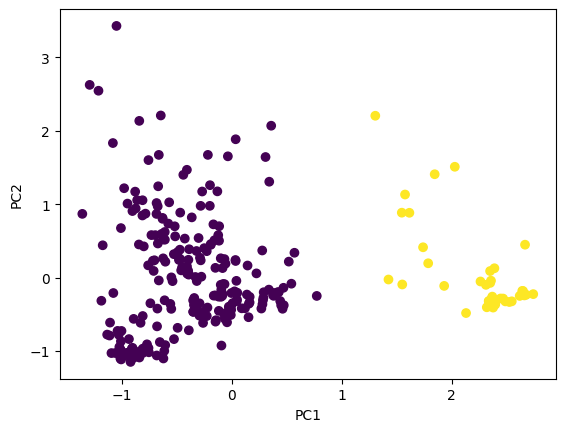

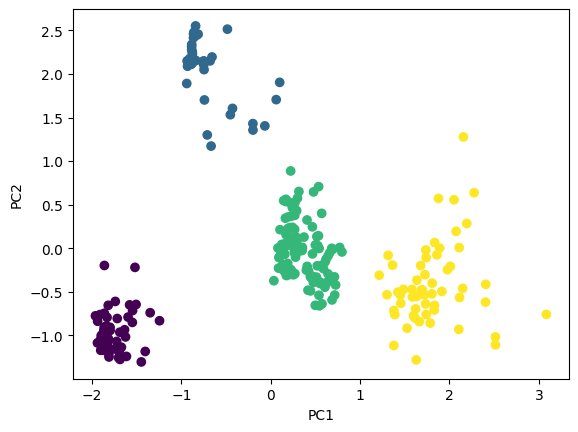

In [19]:
cluster_and_show(n_clusters=2)
cluster_and_show(n_clusters=4)

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
0                     6.761728   4.310187   1.737500  22.218167   
1                    63.537707   5.619206  47.310843  73.460501   
2                    27.639089   5.794394  16.166667  42.872490   
3                    17.613182  11.340672   4.636000  55.329807   
4                    24.151094   6.858369  12.765000  45.424243   

        mean_ram_used_mb                                          \
                    mean          std          min           max   
cluster                                                            
0           13406.646839  4062.502570  8451.416748  21702.772358   
1           20857.958449  3334.315582  4220.743938  24726.250000   
2            3447.642701   254.071185  2588.723328   4047.323743   
3           12991.065395  5327.600045  2823.696663  19947.100000   
4            5071.505218  4192.715495  2660.485742  18245.840000   

        time_per_1000_steps_sec                                     
                           mean         std        min         max  
cluster                                                             
0                      1.445106    1.424372   0.412098    8.201914  
1                      2.695701    5.415037   0.230291   23.334980  
2                      2.199043    1.414930   0.627457    5.954784  
3                    145.810584  232.067363  15.905077  912.552125  
4                     18.268691   14.956229   5.794304   69.295352

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
0,11,6,6,5,5,5,5,6,5,5,5
1,10,6,6,6,0,6,2,2,1,2,2
2,14,6,10,8,1,9,10,9,7,10,12
3,0,1,2,4,2,2,1,0,4,0,1
4,10,6,12,4,1,6,5,6,3,6,3


training_type,ppo,sac
cluster,,
0,60,4
1,36,7
2,84,12
3,1,16
4,11,51


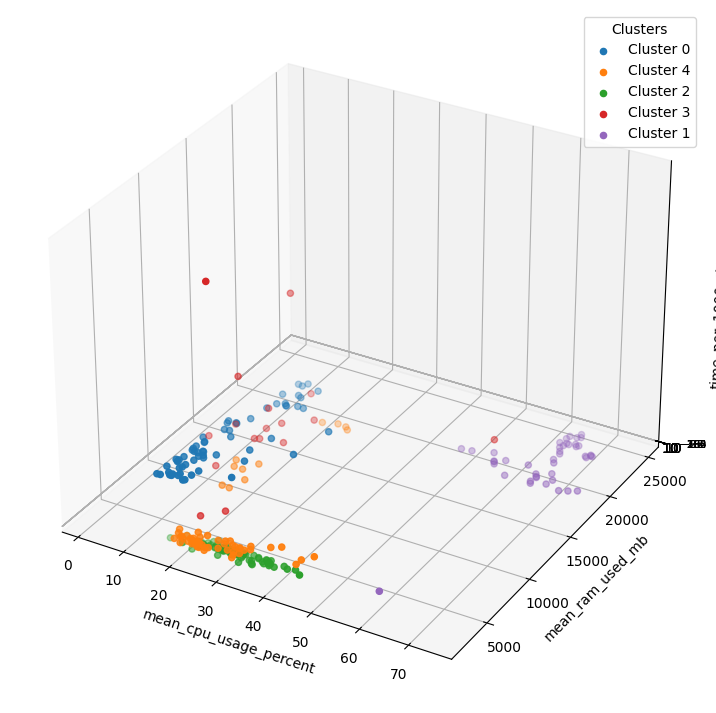

In [68]:
X_sanitized, df_sanitized = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled, X_scaled_as_array = get_scaled_df_and_np(X_sanitized)
kmeans = KMeans(n_clusters=5, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X_scaled_as_array)
X_sanitized["cluster"] = labels
cluster_summary = (
    X_sanitized
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)
display(cluster_summary)
pd.Series(labels).value_counts()
df_sanitized_with_clusters = df_sanitized.copy()
df_sanitized_with_clusters["cluster"] = labels
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["game_name"]))
display(pd.crosstab(df_sanitized_with_clusters["cluster"],df_sanitized_with_clusters["training_type"]))
show_clustered_3d_log(X_sanitized)


In [21]:
X_sanitized.corr()
X_sanitized["cluster"].value_counts()

cluster
2    96
0    64
4    62
1    43
3    17
Name: count, dtype: int64

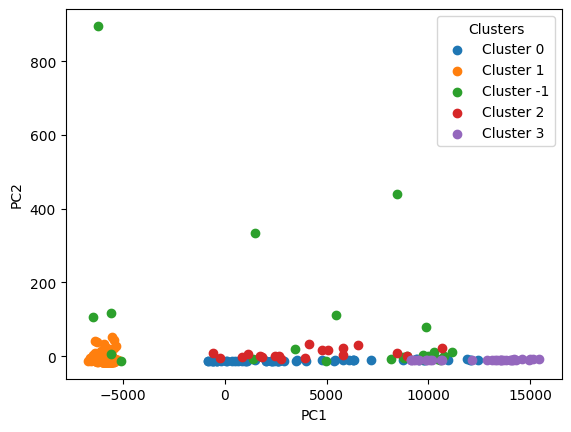

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   36.529888  20.672755   4.636000  73.460501   
 0                    6.064332   3.277430   1.737500  14.785976   
 1                   26.762510   6.090325  16.153333  45.424243   
 2                   14.774871   3.519107   5.927114  22.822000   
 3                   65.331050   3.198255  56.639431  71.812450   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          14626.424451  6290.582936   2823.696663  20464.625000   
 0          13395.251156  4179.939478   8451.416748  21702.772358   
 1           3392.356724   312.983623   2588.723328   4047.323743   
 2          13333.295610  3124.149567   8734.066699  19947.100000   
 3          21714.412660  2156.818618  18424.992647  24726.250000   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                    94.508912  203.439591  0.412098  912.552125  
 0                     1.195750    0.906296  0.471672    4.165636  
 1                     8.118052   12.593481  0.627457   69.295352  
 2                    20.623944   11.692512  5.403695   46.317793  
 3                     0.623826    0.425462  0.230291    1.826646

cluster
 1    146
 0     59
 3     33
-1     25
 2     19
Name: count, dtype: int64

In [52]:
from sklearn.cluster import DBSCAN
X_sanitized_dbscan, df_sanitized_dbscan = get_sanitized_and_subsampled_features_and_org_df(df)
X_scaled_dbscan, X_scaled_as_array_dbscan = get_scaled_df_and_np(X_sanitized_dbscan)

dbscan = DBSCAN(eps = 0.4, min_samples = 5)
labels = dbscan.fit_predict(X_scaled_as_array_dbscan)
X_sanitized_dbscan["cluster"] = labels
df_sanitized_dbscan["cluster"] = labels
show_clustered(X_sanitized_dbscan)

cluster_dbscan_summary = (
    X_sanitized_dbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_dbscan_summary)
X_sanitized_dbscan["cluster"].value_counts()

In [23]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["game_name"]))

cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,10,8,0,2,2,3
0,54,0,5,0,0,0
1,0,0,0,0,81,65
2,19,0,0,0,0,0
3,0,30,0,3,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,6,1,1,3,1,3,2,1,5,1,1
0,10,5,5,5,5,5,4,6,4,5,5
1,20,9,20,11,2,14,15,15,10,15,15
2,1,5,5,3,1,1,1,0,0,1,1
3,8,5,5,5,0,5,1,1,1,1,1


In [24]:
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan[df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor"]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab(df_sanitized_dbscan["cluster"], df_sanitized_dbscan["os"]))
display(pd.crosstab(df_sanitized_dbscan["cpu"], df_sanitized_dbscan["max_cpu_frequency"]))
display(pd.crosstab( df_sanitized_dbscan["cluster"], df_sanitized_dbscan["cpu"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
cluster,,,,,,,,,,,
-1,4,0,0,1,1,1,1,0,2,0,0
0,5,5,5,5,5,5,4,6,4,5,5
2,1,5,5,3,1,1,1,0,0,1,1


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cluster,,,,,
-1,5,5,2,3,10
0,42,17,0,0,0
1,0,0,81,65,0
2,18,1,0,0,0
3,0,0,0,0,33


os,Windows 11,macOS
cluster,,
-1,20,5
0,59,0
1,0,146
2,19,0
3,33,0


max_cpu_frequency,2267.333252,2267.333252,2336.000000,2536.000000,3133.333252
cpu,,,,,
AMD Ryzen 7 5700X 8-Core Processor,65,18,0,0,0
AMD Ryzen 7 9800X3D 8-Core Processor,0,0,0,0,38
"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",0,5,0,0,0
"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",0,0,0,0,5
Apple M1,0,0,83,0,0
Apple M2,0,0,0,68,0


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,10,8,0,2,2,3
0,54,0,5,0,0,0
1,0,0,0,0,81,65
2,19,0,0,0,0,0
3,0,30,0,3,0,0


In [25]:
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "Apple M2")]["game_name"]))
display(pd.crosstab(df_sanitized_dbscan["training_type"], df_sanitized_dbscan[(df_sanitized_dbscan["cpu"] == "AMD Ryzen 7 5700X 8-Core Processor")]["game_name"]))

game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,2,5,5,5,5,5,5
sac,5,5,5,1,0,0,0,0,0,0,0


game_name,3DBall,3DBallHard,Crawler,GridFoodCollector,GridWorld,Hallway,PushBlock,Pyramids,Sorter,Walker,Worm
training_type,,,,,,,,,,,
ppo,5,5,5,5,5,5,5,5,5,5,5
sac,5,5,5,4,2,2,1,1,1,1,1


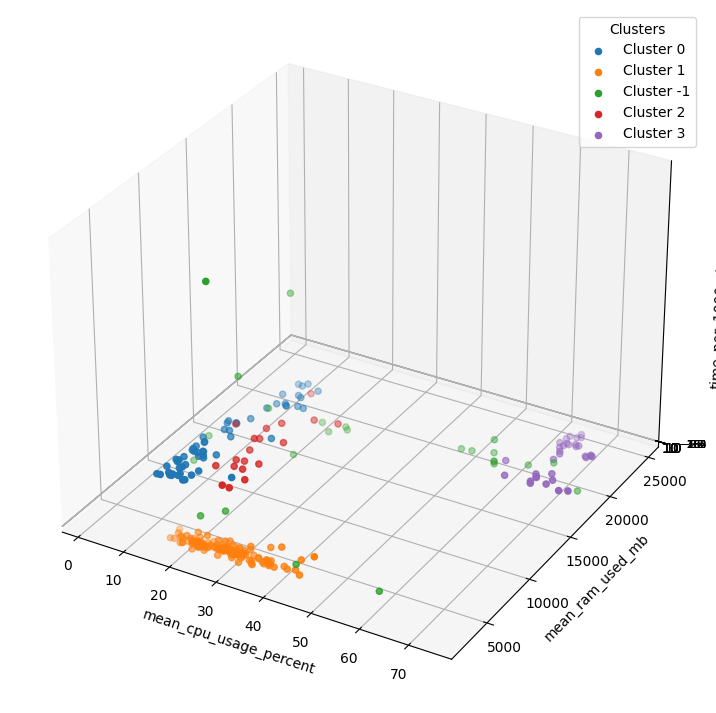

In [67]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

def show_clustered_3d_log(X_with_clusters) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    clusters = X_with_clusters["cluster"].unique()

    for cluster in clusters:
        mask = X_with_clusters["cluster"] == cluster
        ax.scatter(
            X_with_clusters.loc[mask, "mean_cpu_usage_percent"],
            X_with_clusters.loc[mask, "mean_ram_used_mb"],
            X_with_clusters.loc[mask, "time_per_1000_steps_sec"],
            label=f"Cluster {cluster}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="Clusters")
    plt.show()

show_clustered_3d_log(X_sanitized_dbscan)

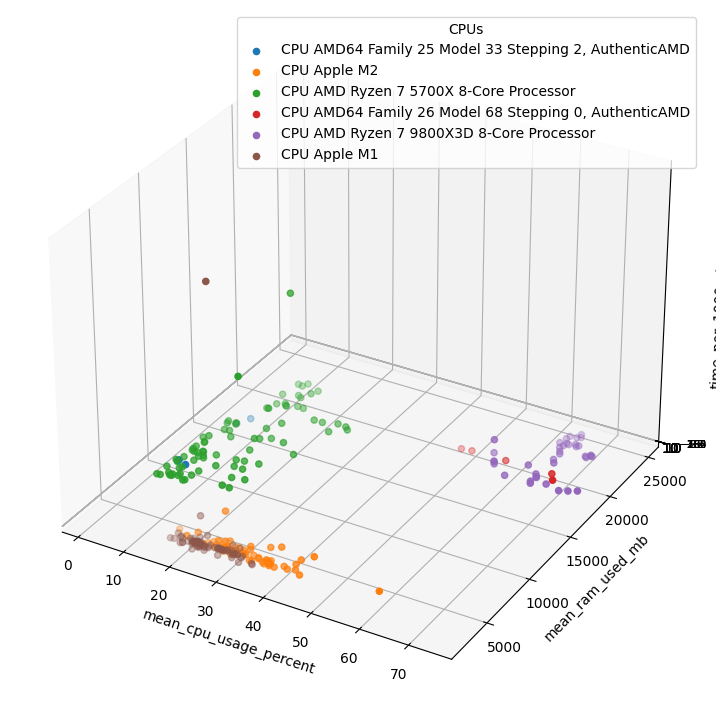

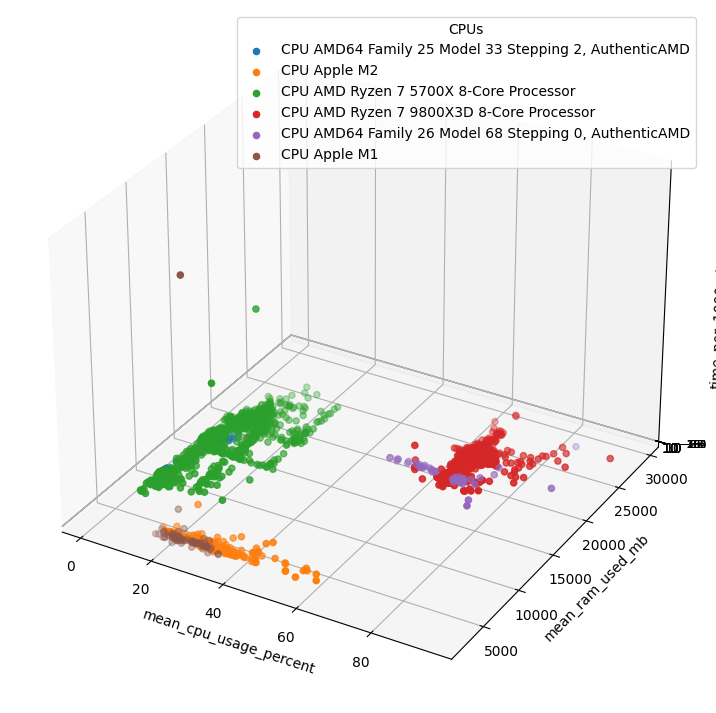

In [40]:
def show_by_cpu_3d_log(X) -> None:
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection="3d")

    cpus = X["cpu"].unique()

    for cpu in cpus:
        mask = X["cpu"] == cpu
        ax.scatter(
            X.loc[mask, "mean_cpu_usage_percent"],
            X.loc[mask, "mean_ram_used_mb"],
            X.loc[mask, "time_per_1000_steps_sec"],
            label=f"CPU {cpu}"
        )

    # Logarithmic scales
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_zscale("log")

    # Axis labels
    ax.set_xlabel("mean_cpu_usage_percent")
    ax.set_ylabel("mean_ram_used_mb")
    ax.set_zlabel("time_per_1000_steps_sec")

    ax.legend(title="CPUs")
    plt.show()

show_by_cpu_3d_log(df_sanitized_dbscan)
show_by_cpu_3d_log(df)

In [28]:
display(static_df[["cpu", "system_ram_gb"]].drop_duplicates())
display(static_df[["gpu", "system_ram_gb"]].drop_duplicates())

,cpu,system_ram_gb
0,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD",34265653248
153,Apple M2,8589934592
203,"AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",66157809664
253,AMD Ryzen 7 9800X3D 8-Core Processor,66157809664
510,AMD Ryzen 7 5700X 8-Core Processor,34265653248
5561,Apple M1,8589934592


,gpu,system_ram_gb
0,NVIDIA GeForce RTX 5080,34265653248
153,Chipset Model: Apple M2,8589934592
203,NVIDIA GeForce RTX 5070 Ti,66157809664
5561,Chipset Model: Apple M1,8589934592


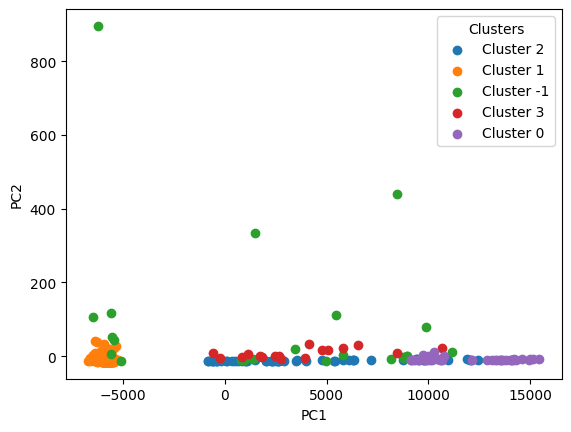

mean_cpu_usage_percent                                   \
                          mean        std        min        max   
cluster                                                           
-1                   25.704594  17.458994   2.935714  65.922497   
 0                   63.613517   5.679071  47.310843  73.460501   
 1                   26.552842   5.848200  16.153333  42.872490   
 2                    5.966209   3.095520   1.737500  13.937805   
 3                   14.821967   2.233793  10.859780  18.477500   

        mean_ram_used_mb                                           \
                    mean          std           min           max   
cluster                                                             
-1          11796.374790  6271.959988   2823.696663  20464.625000   
 0          21273.337667  2138.433908  18424.992647  24726.250000   
 1           3386.673131   311.268383   2588.723328   4047.323743   
 2          13508.590669  4208.329208   8451.416748  21702.772358   
 3          12939.922474  3018.401527   8734.066699  19947.100000   

        time_per_1000_steps_sec                                    
                           mean         std       min         max  
cluster                                                            
-1                   106.902482  209.085857  0.412098  912.552125  
 0                     2.213372    4.458941  0.230291   21.487451  
 1                     7.324442   10.690548  0.627457   57.159785  
 2                     1.117257    0.804069  0.471672    3.740800  
 3                    21.355303   12.170653  5.403695   46.317793

cluster
 1    144
 2     57
 0     41
-1     23
 3     17
Name: count, dtype: int64


cpu,AMD Ryzen 7 5700X 8-Core Processor,AMD Ryzen 7 9800X3D 8-Core Processor,"AMD64 Family 25 Model 33 Stepping 2, AuthenticAMD","AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD",Apple M1,Apple M2
cluster,,,,,,
-1,14,2,0,0,2,5
0,0,36,0,5,0,0
1,0,0,0,0,81,63
2,52,0,5,0,0,0
3,17,0,0,0,0,0


training_type,ppo,sac
cluster,,
-1,7,16
0,35,6
1,93,51
2,57,0
3,0,17


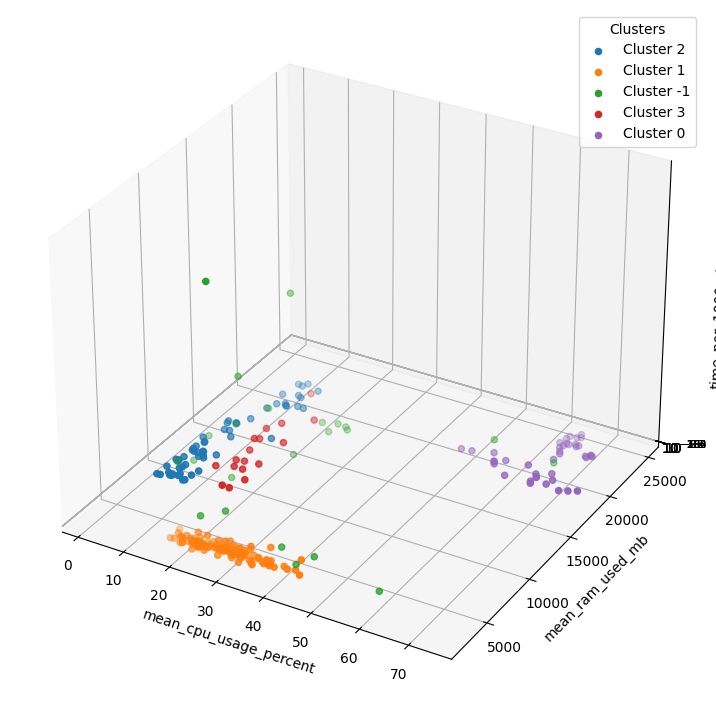

In [69]:
import hdbscan
X_sanitized_hdbscan, df_sanitized_hdbscan = get_sanitized_and_subsampled_features_and_org_df(df, subsample=True, subsample_cap=5)
X_scaled_hdbscan, X_scaled_as_array_hdbscan = get_scaled_df_and_np(X_sanitized_hdbscan)

hdbscan_clf = hdbscan.HDBSCAN()
hdbscan_clf.fit(X_scaled_as_array_hdbscan)
X_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
df_sanitized_hdbscan["cluster"] = hdbscan_clf.labels_
show_clustered(X_sanitized_hdbscan)

cluster_hdbscan_summary = (
    X_sanitized_hdbscan
    .groupby("cluster")[feature_cols]
    .agg(["mean", "std", "min", "max"])
)

display(cluster_hdbscan_summary)
print(X_sanitized_hdbscan["cluster"].value_counts())
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["cpu"]))
display(pd.crosstab(df_sanitized_hdbscan["cluster"], df_sanitized_hdbscan["training_type"]))
show_clustered_3d_log(X_sanitized_hdbscan)